In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
dataset_path = Path("metal_nut")

print("Dataset exists:", dataset_path.exists())
print("Folders:", list(dataset_path.iterdir()))

Dataset exists: True
Folders: [WindowsPath('metal_nut/ground_truth'), WindowsPath('metal_nut/license.txt'), WindowsPath('metal_nut/readme.txt'), WindowsPath('metal_nut/test'), WindowsPath('metal_nut/train')]


In [3]:
train_good = list((dataset_path / "train" / "good").glob("*"))
test_good = list((dataset_path / "test" / "good").glob("*"))

defect_types = ["bent", "color", "flip", "scratch"]

print("Train Good:", len(train_good))
print("Test Good:", len(test_good))

for defect in defect_types:
    count = len(list((dataset_path / "test" / defect).glob("*")))
    print(f"Test {defect}: {count}")

Train Good: 220
Test Good: 22
Test bent: 25
Test color: 22
Test flip: 23
Test scratch: 23


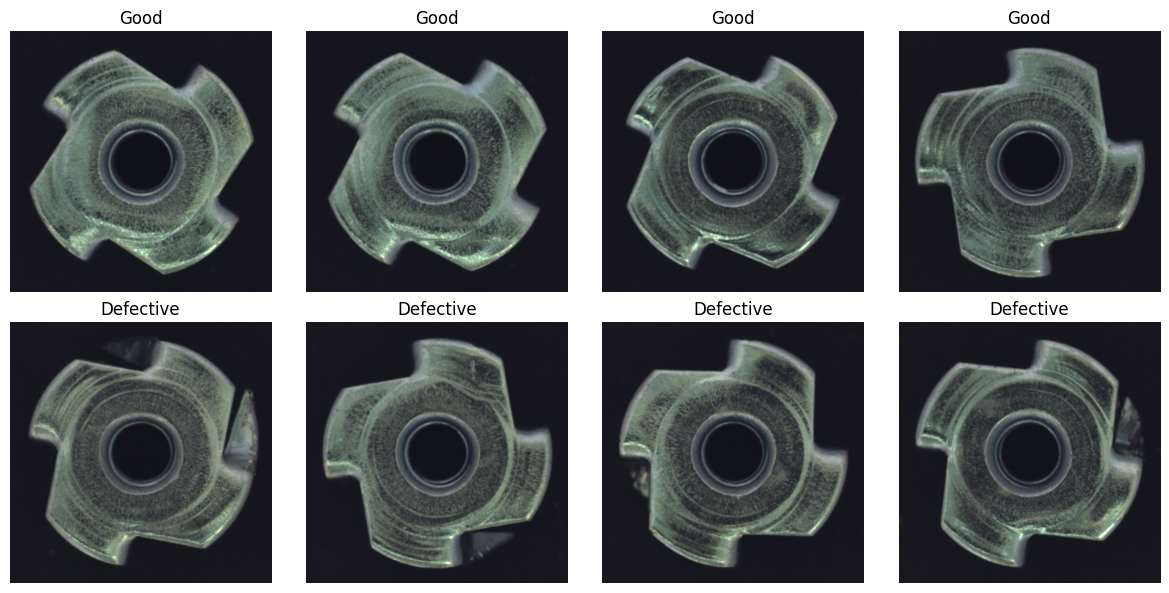

In [4]:
# Show some good and defective images

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Good images
for i in range(4):
    img_path = train_good[i]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img)
    axes[0, i].set_title("Good")
    axes[0, i].axis("off")

# Defective images
defective_paths = []

for defect in defect_types:
    defective_paths.extend(
        list((dataset_path / "test" / defect).glob("*"))
    )

for i in range(4):
    img_path = defective_paths[i]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[1, i].imshow(img)
    axes[1, i].set_title("Defective")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Collect all image paths

good_images = list((dataset_path / "train" / "good").glob("*"))
good_images += list((dataset_path / "test" / "good").glob("*"))

defective_images = []

for defect in defect_types:
    defective_images += list(
        (dataset_path / "test" / defect).glob("*")
    )

print("Good images:", len(good_images))
print("Defective images:", len(defective_images))
print("Total images:", len(good_images) + len(defective_images))

Good images: 242
Defective images: 93
Total images: 335


In [6]:
from sklearn.model_selection import train_test_split

# Create labels
X = good_images + defective_images
y = [0] * len(good_images) + [1] * len(defective_images)

# 0 = Good
# 1 = Defective

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split temporary into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nTrain Good:", y_train.count(0))
print("Train Defective:", y_train.count(1))

print("\nValidation Good:", y_val.count(0))
print("Validation Defective:", y_val.count(1))

print("\nTest Good:", y_test.count(0))
print("Test Defective:", y_test.count(1))

Train: 268
Validation: 33
Test: 34

Train Good: 194
Train Defective: 74

Validation Good: 24
Validation Defective: 9

Test Good: 24
Test Defective: 10


In [7]:
import torch
from torchvision import transforms

# Training augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3)],
        p=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test preprocessing — NO augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [8]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class MetalNutDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = MetalNutDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = MetalNutDataset(
    X_val,
    y_val,
    transform=val_test_transform
)

test_dataset = MetalNutDataset(
    X_test,
    y_test,
    transform=val_test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 268
Validation dataset: 33
Test dataset: 34


In [9]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 17
Validation batches: 3
Test batches: 3


In [10]:
# Get one batch from training data
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])


In [11]:
# Select CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [12]:
# =========================
# MobileNetV2
# =========================

from torchvision import models
import torch.nn as nn

mobilenet = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

for param in mobilenet.parameters():
    param.requires_grad = False

mobilenet.classifier[1] = nn.Linear(
    mobilenet.classifier[1].in_features,
    2
)

mobilenet = mobilenet.to(device)

print(mobilenet)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

In [13]:
import torch.optim as optim

class_weights = torch.tensor(
    [1.0, 194 / 74],
    dtype=torch.float32
).to(device)

criterion_mobilenet = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer_mobilenet = optim.Adam(
    mobilenet.classifier[1].parameters(),
    lr=0.0001
)

print("Class weights:", class_weights)
print("Optimizer:", optimizer_mobilenet)

Class weights: tensor([1.0000, 2.6216])
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [14]:
import torch.optim as optim

# Class weights
class_weights = torch.tensor(
    [1.0, 194 / 74],
    dtype=torch.float32
).to(device)

# Loss function
criterion_mobilenet = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer
optimizer_mobilenet = optim.Adam(
    mobilenet.classifier[1].parameters(),
    lr=0.0001
)

In [15]:
num_epochs = 10

for epoch in range(num_epochs):

    # Training
    mobilenet.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_mobilenet.zero_grad()

        outputs = mobilenet(images)

        loss = criterion_mobilenet(outputs, labels)

        loss.backward()

        optimizer_mobilenet.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # Validation
    mobilenet.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = mobilenet(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.6980 Train Accuracy: 62.31% Val Accuracy: 48.48%
Epoch [2/10] Loss: 0.6854 Train Accuracy: 63.43% Val Accuracy: 66.67%
Epoch [3/10] Loss: 0.6867 Train Accuracy: 67.16% Val Accuracy: 75.76%
Epoch [4/10] Loss: 0.6542 Train Accuracy: 68.66% Val Accuracy: 72.73%
Epoch [5/10] Loss: 0.6353 Train Accuracy: 75.00% Val Accuracy: 78.79%
Epoch [6/10] Loss: 0.6236 Train Accuracy: 73.13% Val Accuracy: 78.79%
Epoch [7/10] Loss: 0.6222 Train Accuracy: 74.63% Val Accuracy: 78.79%
Epoch [8/10] Loss: 0.6122 Train Accuracy: 78.73% Val Accuracy: 78.79%
Epoch [9/10] Loss: 0.6060 Train Accuracy: 76.12% Val Accuracy: 84.85%
Epoch [10/10] Loss: 0.6019 Train Accuracy: 79.48% Val Accuracy: 75.76%


In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

mobilenet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = mobilenet(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test accuracy
test_accuracy = accuracy_score(all_labels, all_preds) * 100

print(f"MobileNetV2 Test Accuracy: {test_accuracy:.2f}%")

MobileNetV2 Test Accuracy: 88.24%


In [17]:
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[24  0]
 [ 4  6]]


In [18]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Good", "Defective"]
))

              precision    recall  f1-score   support

        Good       0.86      1.00      0.92        24
   Defective       1.00      0.60      0.75        10

    accuracy                           0.88        34
   macro avg       0.93      0.80      0.84        34
weighted avg       0.90      0.88      0.87        34

